<a href="https://colab.research.google.com/github/sabrinareyes/fake-news-app/blob/main/step2_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fake News Detection — Step 2: Baseline Models

Turn the cleaned claims from Step 1 into numbers, train a Logistic Regression classifier,
and check honestly whether it beats guessing.

**The number to keep in mind: 56.8%.** That is what you score on the test set by ignoring
the text completely and calling every claim "real". Every result below is reported against
that floor.

Target: **63.5%**, the score Galli et al. (2022) got with the same method.

## 0. Setup

Everything here ships with Colab. `scipy` is used once, for the significance test at the end.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve)

DATA = Path("data")
pd.set_option("display.width", 200)

## 1. Load the cleaned data

Step 1 saved three CSVs. If they are missing — new Colab session, or you are running this
notebook on its own — the cell below rebuilds them from scratch so this notebook always works.

In [2]:
def rebuild_from_scratch():
    """Re-run Step 1 in miniature if the cleaned CSVs are not here."""
    import html, re, urllib.request, zipfile
    DATA.mkdir(exist_ok=True)
    if not (DATA / "train.tsv").exists():
        z = DATA / "liar.zip"
        urllib.request.urlretrieve(
            "https://www.cs.ucsb.edu/~william/data/liar_dataset.zip", z)
        with zipfile.ZipFile(z) as f:
            f.extractall(DATA)

    COLUMNS = ["id", "label", "statement", "subjects", "speaker", "job_title",
               "state_info", "party", "barely_true_ct", "false_ct", "half_true_ct",
               "mostly_true_ct", "pants_fire_ct", "context"]
    LABEL_MAP = {"pants-fire": 1, "false": 1, "barely-true": 1,
                 "half-true": 0, "mostly-true": 0, "true": 0}
    STRICT = {**LABEL_MAP, "half-true": 1}
    URL_RE, TAG_RE, WS_RE = (re.compile(r"https?://\S+|www\.\S+"),
                             re.compile(r"<[^>]+>"), re.compile(r"\s+"))

    def clean(s):
        s = html.unescape(s)
        s = TAG_RE.sub(" ", s)
        s = URL_RE.sub(" ", s)
        s = s.lower().replace("\u2019", "'").replace("\u201c", '"').replace("\u201d", '"')
        return WS_RE.sub(" ", s).strip()

    for name in ("train", "valid", "test"):
        df = pd.read_csv(DATA / f"{name}.tsv", sep="\t", header=None, names=COLUMNS,
                         quoting=3, dtype=str, keep_default_na=False)
        df = df[df["label"].isin(LABEL_MAP)].rename(columns={"label": "label_raw"})
        df["statement"] = df["statement"].map(clean)
        df = df[df["statement"].str.split().str.len() >= 3].copy()
        df["label"] = df["label_raw"].map(LABEL_MAP)
        df["label_strict"] = df["label_raw"].map(STRICT)
        df[["statement", "label_raw", "label", "label_strict"]].to_csv(
            DATA / f"{name}_clean.csv", index=False)
    print("rebuilt cleaned CSVs")


if not (DATA / "train_clean.csv").exists():
    rebuild_from_scratch()

train = pd.read_csv(DATA / "train_clean.csv")
valid = pd.read_csv(DATA / "valid_clean.csv")
test  = pd.read_csv(DATA / "test_clean.csv")

X_train, y_train = train["statement"], train["label"]
X_valid, y_valid = valid["statement"], valid["label"]
X_test,  y_test  = test["statement"],  test["label"]

print(f"train {len(train):>6}   valid {len(valid):>6}   test {len(test):>6}")
train.head(3)

rebuilt cleaned CSVs
train  10261   valid   1284   test   1281


,statement,label_raw,label,label_strict
0,says the annies list political group supports ...,false,1,1
1,when did the decline of coal start? it started...,half-true,0,1
2,"hillary clinton agrees with john mccain ""by vo...",mostly-true,0,0


## 2. The floor

Before training anything, establish what "no skill" looks like. `DummyClassifier` with
`strategy="most_frequent"` never looks at the text — it just answers with whichever label
was more common in training.

Whatever it scores is the number your real model has to beat. If your model cannot, the
model has learned nothing usable, no matter how respectable its accuracy sounds.

In [3]:
dummy = DummyClassifier(strategy="most_frequent").fit(np.zeros((len(y_train), 1)), y_train)
FLOOR = accuracy_score(y_test, dummy.predict(np.zeros((len(y_test), 1))))

print(f"Majority-class baseline on test: {FLOOR:.4f}  ({FLOOR*100:.1f}%)")
print(f"Share of test claims labelled fake: {y_test.mean()*100:.1f}%")
print()
print("This model's report card:")
p_dummy = dummy.predict(np.zeros((len(y_test), 1)))
pr, rc, _, _ = precision_recall_fscore_support(y_test, p_dummy, labels=[1], zero_division=0)
print(f"  accuracy            {FLOOR:.4f}   <- looks respectable")
print(f"  recall on fake      {rc[0]:.4f}   <- catches nothing, which was the whole job")
print(f"  precision on fake   {pr[0]:.4f}   <- never calls anything fake")
print(f"  macro-F1            {f1_score(y_test, p_dummy, average='macro'):.4f}   <- gives it away")

Majority-class baseline on test: 0.5675  (56.8%)
Share of test claims labelled fake: 43.2%

This model's report card:
  accuracy            0.5675   <- looks respectable
  recall on fake      0.0000   <- catches nothing, which was the whole job
  precision on fake   0.0000   <- never calls anything fake
  macro-F1            0.3621   <- gives it away


## 3. Turn text into numbers with TF-IDF

A model cannot read words, so each claim becomes a row of numbers — one column per word (or
word pair) in the vocabulary.

**TF** (term frequency) is how often a word appears in this claim. **IDF** (inverse document
frequency) divides by how many claims contain that word overall. So "the" gets pushed toward
zero because it is everywhere, while "sequestration" keeps its weight. The product is TF-IDF.

The settings below were chosen by testing on the **validation** split, never the test split
— see section 8 for the search. What each one does:

| setting | what it does |
|---|---|
| `ngram_range=(1, 2)` | count single words AND adjacent pairs, so "not true" is its own feature, not just "not" + "true" |
| `min_df=2` | ignore anything appearing in only one claim — those cannot generalise |
| `strip_accents="unicode"` | fold accented characters to plain ASCII |

**Fit on training data only.** `fit_transform` on train learns the vocabulary and the IDF
weights; `transform` on valid and test applies them without looking. Calling `fit` on test
data would leak information about the test set into the model — the single most common way
these projects quietly cheat.

In [5]:
vec = TfidfVectorizer(ngram_range=(1, 2), min_df=2, strip_accents="unicode")

A_train = vec.fit_transform(X_train)   # fit AND transform - training data only
A_valid = vec.transform(X_valid)       # transform only
A_test  = vec.transform(X_test)        # transform only

print(f"vocabulary size: {A_train.shape[1]:,} features")
print(f"train matrix:    {A_train.shape}")
print(f"density:         {A_train.nnz / (A_train.shape[0] * A_train.shape[1]) * 100:.3f}% non-zero")
print()
print("A claim and its non-zero features:")
example = X_train.iloc[0]
print(f"  {example[:90]}...")
row = A_train[0].toarray()[0]
names = vec.get_feature_names_out()
top = np.argsort(row)[-8:][::-1]
for i in top:
    if row[i] > 0:
        print(f"    {names[i]:<28} {row[i]:.3f}")

vocabulary size: 25,713 features
train matrix:    (10261, 25713)
density:         0.100% non-zero

A claim and its non-zero features:
  says the annies list political group supports third-trimester abortions on demand....
    abortions on                 0.315
    trimester abortions          0.315
    political group              0.315
    third trimester              0.315
    trimester                    0.315
    on demand                    0.297
    demand                       0.262
    list                         0.248


## 4. Train Logistic Regression

Logistic Regression learns one weight per feature, adds up the weights of the words present,
and squashes the total into a probability between 0 and 1. Above 0.5 it says fake.

It is the right first model here for three reasons: it trains in a fraction of a second, it
handles tens of thousands of sparse features without complaint, and — unlike most
alternatives — you can read its weights afterwards and see exactly which words drove the
decision. Section 7 does that, and it turns out to be the most interesting part of the project.

`C=0.5` controls regularisation: lower means the model is pushed harder toward small weights,
which limits how much it can memorise the training set. This value came from the validation
search in section 8.

In [6]:
t0 = time.perf_counter()
logreg = LogisticRegression(C=0.5, max_iter=2000, solver="liblinear")
logreg.fit(A_train, y_train)
train_time = time.perf_counter() - t0

print(f"trained in {train_time:.3f} seconds on {A_train.shape[0]:,} claims")

trained in 0.337 seconds on 10,261 claims


## 5. Score it on the test set

This is the first and only time the test set is used for a decision. Everything up to here
was chosen on validation data.

In [7]:
def report(name, y_true, y_pred, scores=None):
    """One row of results, always alongside the floor."""
    acc = accuracy_score(y_true, y_pred)
    pr, rc, f1, _ = precision_recall_fscore_support(y_true, y_pred, labels=[1], zero_division=0)
    out = {
        "model": name,
        "accuracy": round(acc, 4),
        "vs floor": f"{(acc - FLOOR) * 100:+.1f} pts",
        "precision (fake)": round(pr[0], 4),
        "recall (fake)": round(rc[0], 4),
        "F1 (fake)": round(f1[0], 4),
        "macro-F1": round(f1_score(y_true, y_pred, average="macro", zero_division=0), 4),
    }
    if scores is not None:
        out["ROC-AUC"] = round(roc_auc_score(y_true, scores), 4)
    return out


pred_lr = logreg.predict(A_test)
prob_lr = logreg.predict_proba(A_test)[:, 1]

pd.DataFrame([
    report("Majority baseline", y_test, p_dummy),
    report("Logistic Regression", y_test, pred_lr, prob_lr),
])

,model,accuracy,vs floor,precision (fake),recall (fake),F1 (fake),macro-F1,ROC-AUC
0,Majority baseline,0.5675,+0.0 pts,0.0000,0.0000,0.0000,0.3621,NaN
1,Logistic Regression,0.6206,+5.3 pts,0.5966,0.3791,0.4636,0.5850,0.674


### Reading the confusion matrix

The four counts say more than any single number. Rows are the truth, columns are the guess.

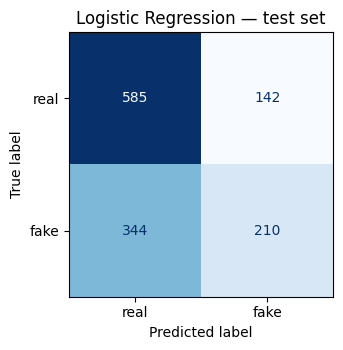

correctly called real    585
correctly called fake    210
WRONGLY called fake      142   <- accuses someone who told the truth
missed a fake claim      344   <- let it through

The model flags 27% of claims as fake, but 43% actually are.
So at the default 0.5 cutoff it is CAUTIOUS - it under-flags. Section 9 revisits this.


In [8]:
cm = confusion_matrix(y_test, pred_lr)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(4.2, 3.6))
ConfusionMatrixDisplay(cm, display_labels=["real", "fake"]).plot(
    ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Logistic Regression — test set")
plt.tight_layout()
plt.show()

print(f"correctly called real   {tn:>4}")
print(f"correctly called fake   {tp:>4}")
print(f"WRONGLY called fake     {fp:>4}   <- accuses someone who told the truth")
print(f"missed a fake claim     {fn:>4}   <- let it through")
print()
print(f"The model flags {(tp+fp)/len(y_test)*100:.0f}% of claims as fake, but {y_test.mean()*100:.0f}% actually are.")
print("So at the default 0.5 cutoff it is CAUTIOUS - it under-flags. Section 9 revisits this.")

## 6. Compare against two other classical models

The benchmark paper compared a family of classifiers, so we do the same. All three see
**identical features** — the same fitted vectorizer, the same rows — so the comparison is fair.

- **Linear SVM** draws the widest possible boundary between the two classes. Usually strong
  on sparse text.
- **Multinomial Naive Bayes** assumes every word contributes independently. That assumption
  is plainly false for language, yet it is fast and often surprisingly competitive.

In [9]:
models = {
    "Logistic Regression": LogisticRegression(C=0.5, max_iter=2000, solver="liblinear"),
    "Linear SVM":          LinearSVC(C=0.1),
    "Multinomial NB":      MultinomialNB(alpha=1.0),
}

rows, preds, timings = [report("Majority baseline", y_test, p_dummy)], {}, {}
for name, m in models.items():
    t0 = time.perf_counter()
    m.fit(A_train, y_train)
    timings[name] = time.perf_counter() - t0
    p = m.predict(A_test)
    preds[name] = p
    s = m.decision_function(A_test) if hasattr(m, "decision_function") else m.predict_proba(A_test)[:, 1]
    rows.append(report(name, y_test, p, s))

results = pd.DataFrame(rows)
results

,model,accuracy,vs floor,precision (fake),recall (fake),F1 (fake),macro-F1,ROC-AUC
0,Majority baseline,0.5675,+0.0 pts,0.0000,0.0000,0.0000,0.3621,NaN
1,Logistic Regression,0.6206,+5.3 pts,0.5966,0.3791,0.4636,0.5850,0.6740
2,Linear SVM,0.6183,+5.1 pts,0.5858,0.4007,0.4759,0.5879,0.6750
3,Multinomial NB,0.6097,+4.2 pts,0.6038,0.2834,0.3857,0.5499,0.6694


In [10]:
print("Training time — the axis where the simple models win outright:")
for name, t in timings.items():
    print(f"  {name:<22} {t:.3f} s")
print()
print("For reference, Galli et al. report 0.22 s for Logistic Regression and 525.15 s for BERT.")

Training time — the axis where the simple models win outright:
  Logistic Regression    0.531 s
  Linear SVM             0.095 s
  Multinomial NB         0.008 s

For reference, Galli et al. report 0.22 s for Logistic Regression and 525.15 s for BERT.


### Are these differences real?

The test set has 1,281 claims, so one percentage point is about 13 claims. Two models
differing by a fraction of a point are not meaningfully different — the gap is smaller than
the noise.

**McNemar's test** is the right tool. Rather than comparing two percentages as if they came
from separate experiments, it looks claim by claim and counts only the disagreements: cases
where one model was right and the other wrong. If those disagreements split roughly evenly,
the models are equivalent.

A p-value above 0.05 means: no evidence these two models differ.

In [11]:
from scipy.stats import binomtest
from itertools import combinations

print(f"{'comparison':<46} {'A only':>7} {'B only':>7} {'p':>8}")
for a, b in combinations(models, 2):
    ra, rb = preds[a] == y_test.values, preds[b] == y_test.values
    n_a_only, n_b_only = int((ra & ~rb).sum()), int((~ra & rb).sum())
    p = binomtest(min(n_a_only, n_b_only), n_a_only + n_b_only, 0.5).pvalue
    verdict = "same" if p > 0.05 else "DIFFERENT"
    print(f"{a + ' vs ' + b:<46} {n_a_only:>7} {n_b_only:>7} {p:>8.3f}  {verdict}")

comparison                                      A only  B only        p
Logistic Regression vs Linear SVM                   20      17    0.743  same
Logistic Regression vs Multinomial NB               85      71    0.298  same
Linear SVM vs Multinomial NB                        87      76    0.434  same


## 7. What did the model actually learn?

This is the most revealing cell in the project, and the one to build your write-up around.

Because Logistic Regression keeps one weight per feature, we can just sort them. Positive
weights push toward **fake**, negative toward **real**.

In [12]:
names = np.array(vec.get_feature_names_out())
coef = logreg.coef_[0]
order = np.argsort(coef)

top_fake = pd.DataFrame({"token": names[order[-20:]][::-1], "weight": coef[order[-20:]][::-1].round(3)})
top_real = pd.DataFrame({"token": names[order[:20]],        "weight": coef[order[:20]].round(3)})

pd.concat([top_fake.add_prefix("fake_"), top_real.add_prefix("real_")], axis=1)

,fake_token,fake_weight,real_token,real_weight
0,obamacare,1.325,than,-2.049
1,obama,1.286,percent,-1.778
2,wisconsin,1.277,more,-1.658
3,rep,1.046,since,-1.633
4,to,1.027,of,-1.294
5,will,0.977,million,-1.290
6,government,0.961,day,-1.242
7,says,0.939,georgia,-1.209
8,scott walker,0.899,countries,-1.191
9,walker,0.893,he,-1.167


### Look closely at that list — this is the finding

The words pushing toward **fake** are overwhelmingly *people and topics*: `obama`,
`obamacare`, `scott walker`, `wisconsin`, `government`, `president`. These are not markers of
dishonesty. They are markers of **subject matter**.

The words pushing toward **real** are overwhelmingly *numbers and measurement*: `percent`,
`million`, `more than`, `000`, `three`, `average`, `times`. Claims citing specific figures
tend to get rated true.

So the model has not learned to detect deception. It has learned two much simpler things:

1. **Which topics attract harsh PolitiFact ratings** — which is a fact about what journalists
   chose to fact-check between 2007 and 2016, not about truth.
2. **That specific numbers correlate with accurate claims** — a real pattern, but a stylistic
   one. Any practised liar could cite a fake statistic and slip straight past this model.

This is the honest headline of the whole project, and it matches published findings: the 2021
study *"To trust a LIAR"* found models on this dataset were largely learning speaker
reputation rather than veracity. Say this plainly in your write-up. It is a far stronger
result than a slightly higher accuracy number would be, because it explains *why* the ceiling
is where it is.

## 8. Where the settings came from

The grid below is the honest record of how `ngram_range`, `min_df` and `C` were chosen —
**scored on the validation split, never on test**. Test data was untouched until section 5.

This takes a minute or so to run.

In [13]:
grid = []
for ngram in [(1, 1), (1, 2)]:
    for min_df in [1, 2, 3]:
        v = TfidfVectorizer(ngram_range=ngram, min_df=min_df, strip_accents="unicode")
        At, Av = v.fit_transform(X_train), v.transform(X_valid)
        for C in [0.1, 0.5, 1.0, 3.0, 10.0]:
            m = LogisticRegression(C=C, max_iter=2000, solver="liblinear").fit(At, y_train)
            grid.append({"ngram": str(ngram), "min_df": min_df, "C": C,
                         "features": At.shape[1],
                         "valid accuracy": round(accuracy_score(y_valid, m.predict(Av)), 4)})

pd.DataFrame(grid).sort_values("valid accuracy", ascending=False).head(10).reset_index(drop=True)

,ngram,min_df,C,features,valid accuracy
0,"(1, 2)",2,0.5,25713,0.6371
1,"(1, 2)",3,0.5,14898,0.6324
2,"(1, 2)",1,0.5,95429,0.6285
3,"(1, 2)",1,10.0,95429,0.6269
4,"(1, 2)",1,1.0,95429,0.6262
5,"(1, 2)",1,3.0,95429,0.6262
6,"(1, 2)",2,3.0,25713,0.6246
7,"(1, 2)",2,1.0,25713,0.6246
8,"(1, 1)",3,0.5,4981,0.6246
9,"(1, 2)",3,1.0,14898,0.6231


## 9. Choosing the cutoff

The model outputs a probability. Calling anything above **0.5** fake is only a default, not a
rule — and it is worth questioning, because the two mistakes are not equally bad:

- **Wrongly flagging a true claim** accuses someone who did nothing wrong.
- **Missing a fake claim** leaves things exactly as they were without the model.

The sweep below is scored on **validation**, so picking a cutoff from it is legitimate.
Choosing one by looking at test scores would be tuning on the test set — the thing we have
been careful to avoid all the way through.

In [14]:
prob_valid = logreg.predict_proba(A_valid)[:, 1]

sweep = []
for thr in np.arange(0.30, 0.71, 0.05):
    p = (prob_valid >= thr).astype(int)
    pr, rc, _, _ = precision_recall_fscore_support(y_valid, p, labels=[1], zero_division=0)
    sweep.append({"cutoff": round(thr, 2),
                  "valid accuracy": round(accuracy_score(y_valid, p), 4),
                  "precision (fake)": round(pr[0], 4),
                  "recall (fake)": round(rc[0], 4),
                  "macro-F1": round(f1_score(y_valid, p, average="macro", zero_division=0), 4),
                  "% flagged": round(100 * p.mean(), 1)})

sweep = pd.DataFrame(sweep)
best_thr = float(sweep.loc[sweep["macro-F1"].idxmax(), "cutoff"])
print(f"Best macro-F1 on validation at cutoff {best_thr}")
sweep

Best macro-F1 on validation at cutoff 0.45


,cutoff,valid accuracy,precision (fake),recall (fake),macro-F1,% flagged
0,0.30,0.5382,0.5102,0.9351,0.4698,87.9
1,0.35,0.5670,0.5299,0.8620,0.5356,78.0
2,0.40,0.6067,0.5688,0.7451,0.6020,62.9
3,0.45,0.6332,0.6214,0.6023,0.6321,46.5
4,0.50,0.6371,0.6856,0.4497,0.6211,31.5
5,0.55,0.6121,0.7479,0.2890,0.5632,18.5
6,0.60,0.5646,0.7478,0.1396,0.4655,9.0
7,0.65,0.5483,0.8103,0.0763,0.4166,4.5
8,0.70,0.5335,0.9048,0.0308,0.3747,1.6


Now apply that validation-chosen cutoff to the test set — once.

In [15]:
pred_tuned = (prob_lr >= best_thr).astype(int)

pd.DataFrame([
    report("Majority baseline", y_test, p_dummy),
    report("Logistic Regression (cutoff 0.50)", y_test, pred_lr, prob_lr),
    report(f"Logistic Regression (cutoff {best_thr})", y_test, pred_tuned, prob_lr),
])

,model,accuracy,vs floor,precision (fake),recall (fake),F1 (fake),macro-F1,ROC-AUC
0,Majority baseline,0.5675,+0.0 pts,0.0000,0.0000,0.0000,0.3621,NaN
1,Logistic Regression (cutoff 0.50),0.6206,+5.3 pts,0.5966,0.3791,0.4636,0.5850,0.674
2,Logistic Regression (cutoff 0.45),0.6370,+6.9 pts,0.5788,0.5903,0.5845,0.6311,0.674


Moving the cutoff from 0.50 to 0.45 trades a little precision for a lot of recall, and both
accuracy and macro-F1 improve. The model stops being so cautious about calling things fake.

Note that ROC-AUC is identical across both rows — the cutoff does not change how well the
model *ranks* claims, only where the line is drawn. That is exactly what AUC is for.

## 10. Save the model for the app

Step 4 loads these two files. The vectorizer must be saved with the model: a claim typed
into the app has to be converted using the **same vocabulary and IDF weights** learned here,
or the numbers will mean something different.

In [16]:
import joblib

joblib.dump({"vectorizer": vec, "model": logreg, "threshold": best_thr,
             "floor": FLOOR}, "fake_news_model.joblib")

bundle = joblib.load("fake_news_model.joblib")
demo = ["the unemployment rate has dropped to 3.5 percent, the lowest in 50 years",
        "obamacare will create government death panels to decide who lives"]
p = bundle["model"].predict_proba(bundle["vectorizer"].transform(demo))[:, 1]
for claim, prob in zip(demo, p):
    verdict = "FAKE" if prob >= bundle["threshold"] else "REAL"
    print(f"{verdict}  {prob:.1%} confidence fake  |  {claim[:60]}...")

REAL  33.5% confidence fake  |  the unemployment rate has dropped to 3.5 percent, the lowest...
FAKE  68.7% confidence fake  |  obamacare will create government death panels to decide who ...


## 11. Summary for the write-up

| | value |
|---|---|
| Majority-class floor | **56.8%** |
| Logistic Regression, default cutoff | **62.1%** (+5.3 pts) |
| Logistic Regression, cutoff tuned on validation | **63.7%** (+7.0 pts) |
| Published target (Galli et al. 2022) | 63.5% |
| Linear SVM | 61.8% |
| Multinomial Naive Bayes | 61.0% |

**What to claim.** The model beats the trivial baseline by about 7 points, and lands level
with the published benchmark. That is a real result, and small.

**What not to claim.** Do not say Logistic Regression beat Linear SVM — McNemar's test says
those two are statistically indistinguishable. Do not describe this as detecting fake news;
it detects *topics and writing style associated with harsh PolitiFact ratings in US politics
between 2007 and 2016*.

**The most interesting result is in section 7**, not in the accuracy table. The model's
strongest signals for "fake" are politicians' names, and its strongest signals for "real" are
numbers. That explains the ceiling far better than any hyperparameter discussion, and it is
the part worth presenting.

## Next: Step 4 (or Step 3 if you have time)

- **Step 3, stretch:** fine-tune BERT and compare. Expect roughly the same accuracy at
  thousands of times the training cost — which is itself the finding.
- **Step 4:** wrap `fake_news_model.joblib` in a Streamlit app that takes a claim and returns
  a verdict with a confidence score.